In [3]:
# libray 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Import the dataset 
df = pd.read_csv(r"C:\Users\Raifu Sodiq\Desktop\To do\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
# Check the first fOUR rows of the dataset
df.head(4)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No


In [6]:
# get information of the data 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# Convert TotalCharges from object to float 
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'].dtype

dtype('float64')

In [8]:
# Check missing number 
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
# fill the missing numbers with the median 
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [10]:
# check if there is duplicate
df.duplicated().sum()


np.int64(0)

  # PERFORM EXPLORATORY DATA ANALYSIS

In [11]:
# select object column 
df.select_dtypes("object").columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [12]:
# Which Payment method did people use most 
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

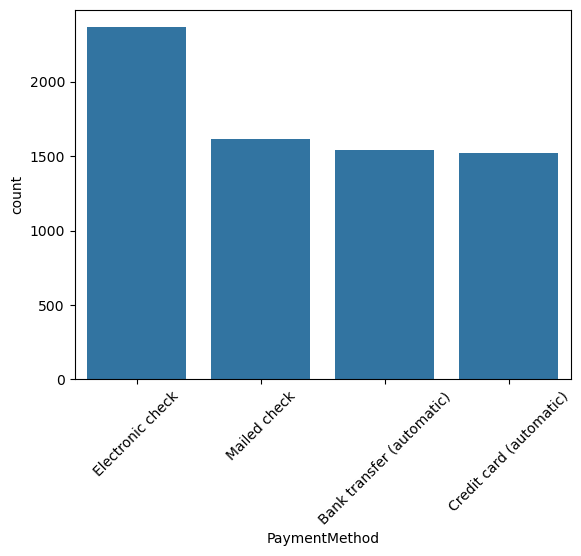

In [13]:
sns.countplot(data=df, x="PaymentMethod")

plt.xticks(rotation=45) 
plt.show()

In [14]:
       # This shows that the mostly used Payment method is Electronics check ( Used by 2365 users ) followed     
       # by Mailed Check (Used by 1612 users) and Bank transfer and Creadit Card has a difference of 22 users 

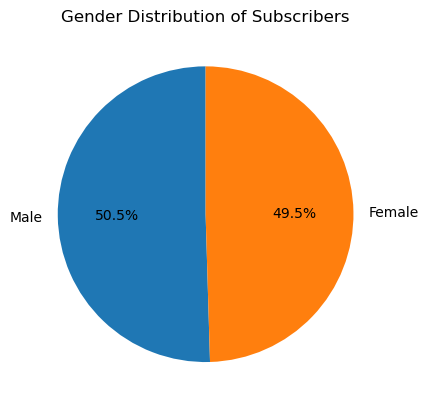

In [15]:
    # Checking the gender that use subscribe most

gender_counts = df['gender'].value_counts()

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Gender Distribution of Subscribers")
plt.show()

Text(0.5, 1.0, 'Heatmap showing the correlation between numeric variables')

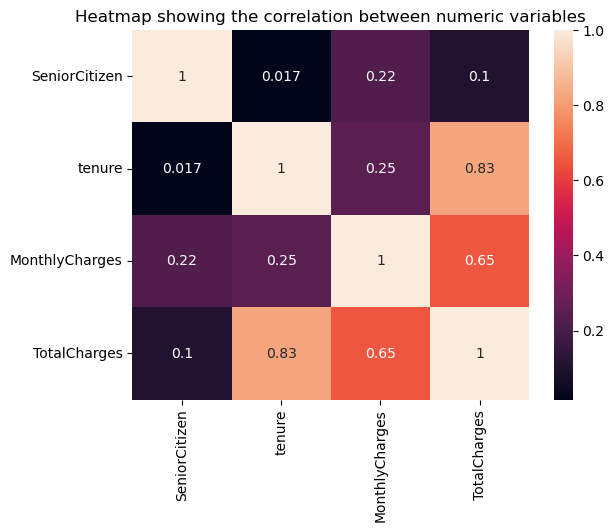

In [17]:
# plot a heetmap to show the correlation between variables)
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot = True)
plt.title("Heatmap showing the correlation between numeric variables")

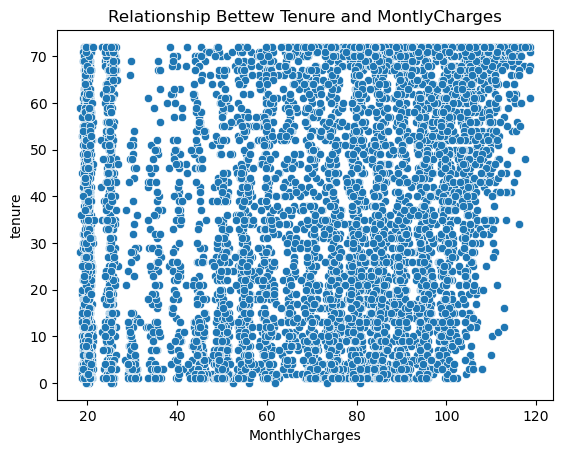

In [60]:
# Let check the relationship between montly charges and tenure using scatter plot 
sns.scatterplot(y = "tenure", 
                x = "MonthlyCharges", 
data = df)
plt.title("Relationship Bettew Tenure and MontlyCharges")
plt.show()

# Let Explore More on the churn variable 

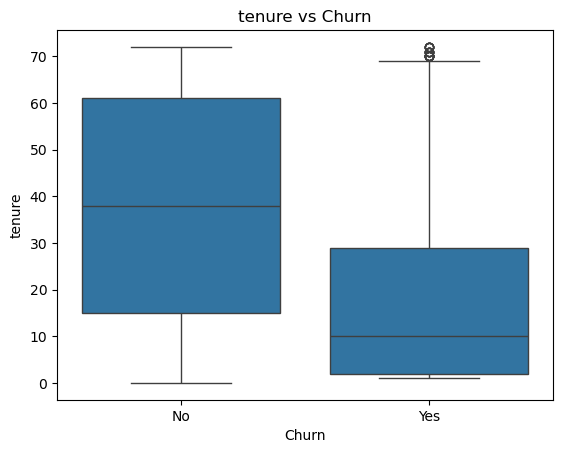

In [61]:
# Check Tenurn and Churn 

sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("tenure vs Churn")
plt.show()

In [62]:
  # This show that half of those who didnot churn have stayed for about 38 months and any customers staying from 28 mpnths are not likely to churn
  #  Also most of the churning happen between 2 to 25 months and half of those who churn do so around 10 months

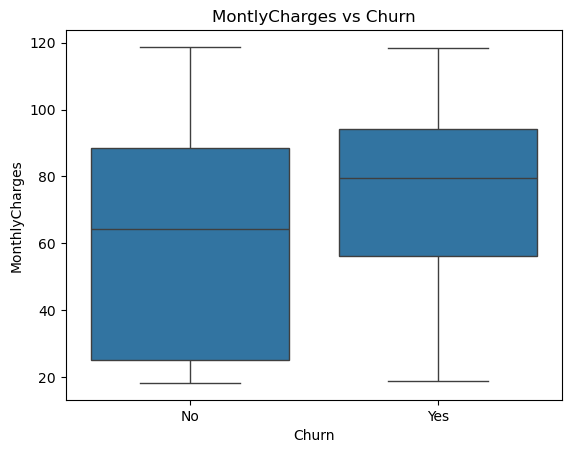

In [63]:
# Checking relationship between montlycharges and churn
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("MontlyCharges vs Churn")
plt.show()

In [64]:
       # This shows that customers paying "premium" prices (between $60 and $100) are much more likely to leave than those on the budget plans.

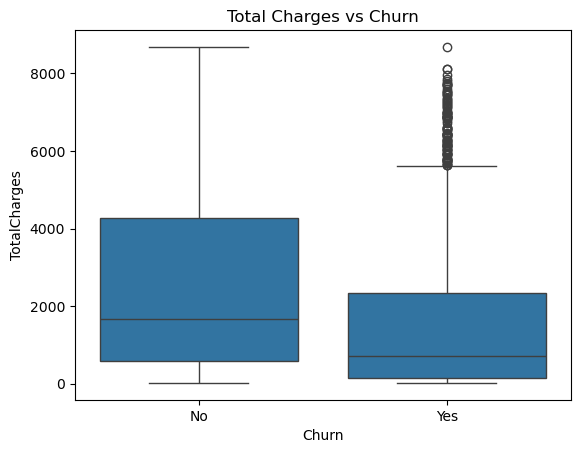

In [65]:
# Check the TotalCharges and Churn  
sns.boxplot(data=df, x="Churn", y="TotalCharges")
plt.title("Total Charges vs Churn")
plt.show()

# SURVIVAL ANALYSIS

In [67]:
from lifelines import KaplanMeierFitter

In [68]:
# Get the dataset to carryout survival analysis  
sur = df 

In [69]:
# Work on the Churn Variable by converting Yes to 1 (Event) and No to 0 (censored)

sur.loc[sur["Churn"] == "No", "Churn"] = 0
sur.loc[sur["Churn"] == "Yes", "Churn"] = 1
sur["Churn"] = sur["Churn"].astype("int")       # set the Churn varible to int 

In [70]:
# Create a list of categorical column and remove customer_ID columns 
cat_col = sur.select_dtypes('object').columns.drop('customerID')
for col in cat_col:
    print('Column Name', col)
    print(df[col].value_counts())
    print('______________________________________')


Column Name gender
gender
Male      3555
Female    3488
Name: count, dtype: int64
______________________________________
Column Name Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64
______________________________________
Column Name Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
______________________________________
Column Name PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
______________________________________
Column Name MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
______________________________________
Column Name InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
______________________________________
Column Name OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
___________

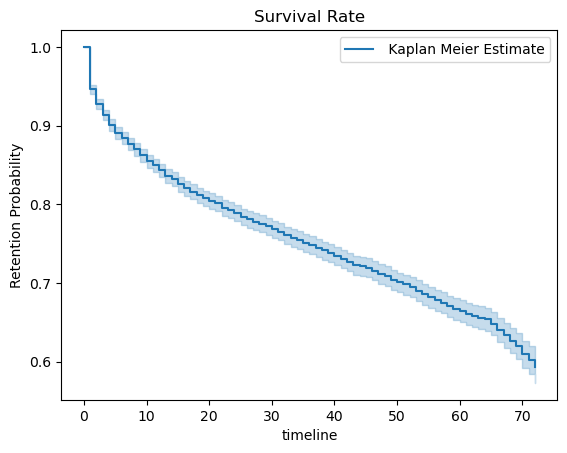

In [71]:
# let create overall kapler curve 
tenure = sur["tenure"]
churn = sur["Churn"]
kap = KaplanMeierFitter()
kap.fit(tenure, churn, label =' Kaplan Meier Estimate')
kap.plot()
plt.title('Survival Rate')
plt.ylabel('Retention Probability')
plt.show()

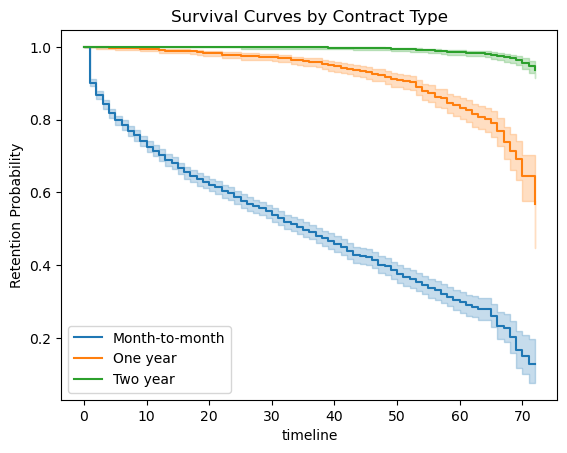

In [85]:
# Survival plot for Contract Type
kmf = KaplanMeierFitter()
ax = plt.subplot(111)

# Loop through each contract type and plot
for name, grouped_df in sur.groupby('Contract'):
    kmf.fit(grouped_df['tenure'], grouped_df['Churn'], label=name)
    kmf.plot(ax=ax)

plt.title('Survival Curves by Contract Type')
plt.ylabel('Retention Probability')
plt.show()

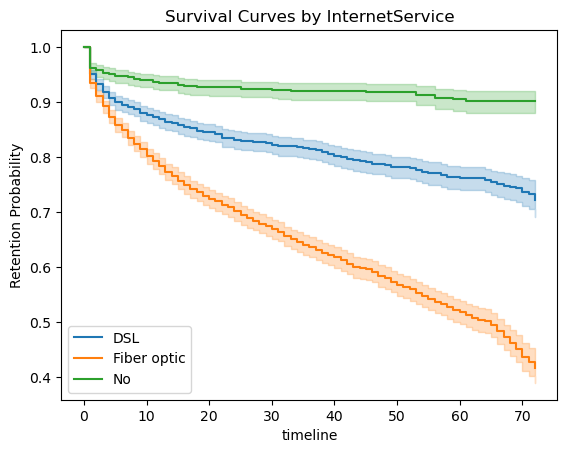

In [86]:
# Survival plot for InternetService
ax = plt.subplot(111)

# Loop through each contract type and plot
for name, grouped_df in sur.groupby('InternetService'):
    kmf.fit(grouped_df['tenure'], grouped_df['Churn'], label=name)
    kmf.plot(ax=ax)

plt.title('Survival Curves by InternetService')
plt.ylabel('Retention Probability')
plt.show()

# Cox Proportional Hazards model (CoxPH) to examine how different variables affect the time until customer churn

In [21]:
from lifelines import CoxPHFitter

# Prepare data and drop the "Customer ID" or any unique strings again
cox_df = df

cox_df = cox_df.drop(columns=['customerID'])

# Convert categorical column to dummies

cox_df = pd.get_dummies(cox_df, drop_first=True)

# instantiate model
cph = CoxPHFitter(penalizer=0.1) 

# 5. Fit
# If Churn became Churn_Yes
cph.fit(cox_df, duration_col='tenure', event_col='Churn_Yes')

# 6. Print
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 7043 total observations, 5174 right-censored observations>
             duration col = 'tenure'
                event col = 'Churn_Yes'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 7043
number of events observed = 1869
   partial log-likelihood = -13928.00
         time fit was run = 2026-05-06 12:45:02 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                              
SeniorCitizen                          0.05      1.05      0.05           -0.05            0.14                0.95                1.15
MonthlyCharges                         0.00      1.00      0.00            0.00            0.01                1.00                1.01
TotalCharges                          -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
gender_Male                           -0.03      0.97      0.04           -0.11            0.04                0.89                1.04
Partner_Yes                           -0.31      0.73      0.04           -0.39           -0.23                0.67                0.80
Dependents_Yes                        -0.15      0.86      0.05           -0.25           -0.05                0.78                0.95
PhoneService_Yes                       0.11      1.12      0.10           -0.08            0.31                0.92                1.36
MultipleLines_No phone service        -0.11      0.90      0.10           -0.31            0.08                0.74                1.09
MultipleLines_Yes                     -0.15      0.86      0.04           -0.24           -0.07                0.79                0.94
InternetService_Fiber optic            0.47      1.60      0.05            0.37            0.58                1.45                1.78
InternetService_No                    -0.22      0.80      0.09           -0.39           -0.06                0.68                0.95
OnlineSecurity_No internet service    -0.22      0.80      0.09           -0.39           -0.06                0.68                0.95
OnlineSecurity_Yes                    -0.43      0.65      0.05           -0.52           -0.33                0.59                0.72
OnlineBackup_No internet service      -0.22      0.80      0.09           -0.39           -0.06                0.68                0.95
OnlineBackup_Yes                      -0.31      0.73      0.04           -0.40           -0.22                0.67                0.80
DeviceProtection_No internet service  -0.22      0.80      0.09           -0.39           -0.06                0.68                0.95
DeviceProtection_Yes                  -0.18      0.83      0.05           -0.27           -0.09                0.76                0.91
TechSupport_No internet service       -0.22      0.80      0.09           -0.39           -0.06                0.68                0.95
TechSupport_Yes                       -0.34      0.71      0.05           -0.43           -0.24                0.65                0.79
StreamingTV_No internet service       -0.22      0.80      0.09           -0.39           -0.06                0.68                0.95
StreamingTV_Yes                        0.04      1.04      0.04           -0.05            0.12                0.95                1.13
StreamingMovies_No internet service   -0.22      0.80      0.09           -0.39           -0.06                0.68                0.95
StreamingMovies_Yes                    0.01      1.01      0.04           -0.08            0.10                0.92                1.10
Contract_One year                     -0.67      0.51      0.06           -0.78           -0.55                0.46                0.58
Contract_Two year              

# Forest Plot to show our Cox Proportional Hazards model

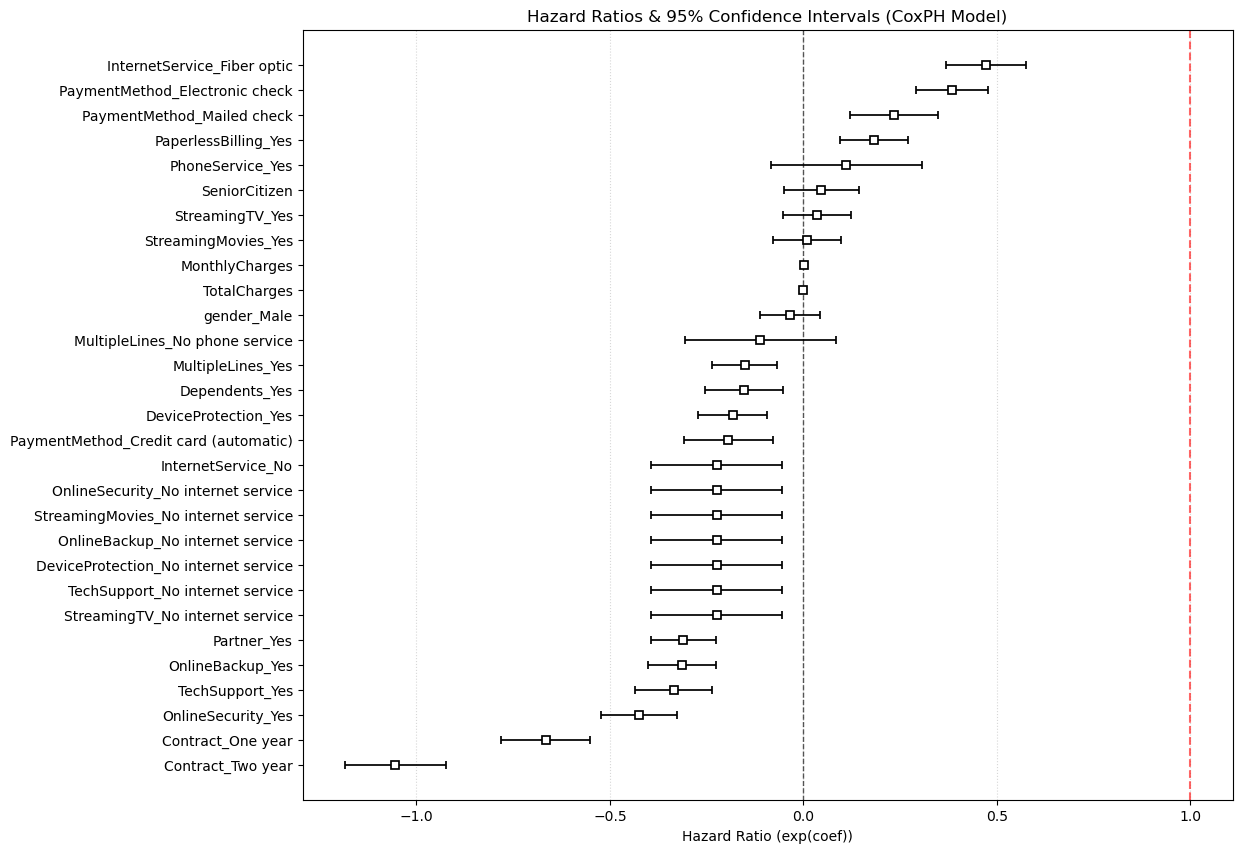

In [92]:
# Set the style to make it look professional
plt.figure(figsize=(12, 10))

# The .plot() method in lifelines automatically creates a Forest Plot
cph.plot()

# Adding a vertical line at 1.0 (The "Neutral" line)
plt.axvline(x=1, color='red', linestyle='--', alpha=0.6)

plt.title('Hazard Ratios & 95% Confidence Intervals (CoxPH Model)')
plt.xlabel('Hazard Ratio (exp(coef))')
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.show()

# Insight and Recommendation

In [ ]:
                                                        # Insight 

                                # High Churn Risk:
# Fiber Optic Service (Hazard Ratio: 1.60): Customers using Fiber Optic are 60% more likely to churn at any given time compared to DSL users. This suggests a potential gap in service quality, pricing, or the onboarding experience for premium high-speed internet.

# Electronic Check Payments (Hazard Ratio: 1.47): This payment method is associated with a 47% increase in churn risk. These customers may be more transient or experiencing friction in the monthly manual payment process.

# Paperless Billing (Hazard Ratio: 1.20): Surprisingly, those opted into paperless billing show a 20% higher risk. This often correlates with a "set it and forget it" mentality that makes it easier for customers to switch providers without physical bill reminders.



                              # Protective Factors (The "Retention Anchors")
# Two-Year Contracts (Hazard Ratio: 0.35): Long-term commitment is the strongest shield, reducing churn risk by 65%.

# Value-Added Services: Online Security and Tech Support reduce churn hazard by 35% and 29% respectively. These services create "product stickiness," making the cost of switching mentally or technically higher for the user.

                                                        #Recommendations
# 1. The "Fiber-to-Loyalty" Initiative
# Investigation: Conduct a technical audit of the Fiber Optic infrastructure in areas with the highest churn to see if downtime or speed throttling is the culprit.

# Bundling: Automatically bundle Tech Support and Online Security (our top retention anchors) with all Fiber Optic plans to stabilize these high-risk, high-value accounts.


# II. Payment Behavior Conversion

# Nudge to Auto-Pay: Offer a small monthly discount (e.g., $2–$5) for customers to move from Electronic Checks (High Risk) to Credit Card/Bank Auto-Pay (Lower Risk: 0.82).

# Engagement: For paperless billing customers, implement monthly "Loyalty Emails" that highlight service value to replace the physical touchpoint of a paper bill.


# III. Strategic Contract Migration
# Incentivize Term Extensions: Target Month-to-Month customers who have survived past the 6-month mark with a "Loyalty Upgrade" to a 1-year contract.


# MODEL

In [75]:
# import library 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix,  classification_report

In [76]:
# Separate X and y variable
y = df["Churn"].values
X = df.drop(columns = ["Churn", "customerID"])

In [77]:
# set y as integer
y = y.astype(int)

In [78]:
# select categorical column
ca_col = X.select_dtypes('object').columns
ca_col

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [79]:
# Encode the categorical column using OneHotEncoder and convert to dataframe

# Instantiate encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and transform categorical columns at once
encoded_data = encoder.fit_transform(X[ca_col])

# Convert to DataFrame
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(ca_col))

In [80]:
# Drop the categorical column in X, and set as da_ta then add encoded_df
da_ta = X.drop(columns=ca_col)
da_ta = pd.concat([da_ta, encoded_df], axis=1).values

In [81]:
da_ta

array([[  0.  ,   1.  ,  29.85, ...,   0.  ,   1.  ,   0.  ],
       [  0.  ,  34.  ,  56.95, ...,   0.  ,   0.  ,   1.  ],
       [  0.  ,   2.  ,  53.85, ...,   0.  ,   0.  ,   1.  ],
       ...,
       [  0.  ,  11.  ,  29.6 , ...,   0.  ,   1.  ,   0.  ],
       [  1.  ,   4.  ,  74.4 , ...,   0.  ,   0.  ,   1.  ],
       [  0.  ,  66.  , 105.65, ...,   0.  ,   0.  ,   0.  ]],
      shape=(7043, 45))

In [82]:
# Split the data_set into train and test set 
X_train,X_test,y_train,y_test = train_test_split(da_ta, y, random_state = 42, test_size = 0.3)

In [38]:
# Build Pipeline
models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]),
    
    "KNN": Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors = 15))
    ]),
    
    "XGBoost": XGBClassifier()  # no scaler needed
}

In [39]:
# create funtion to evaluate all model in the pipeline confusion_matrix

def evaluate_model(name, y_test, y_pred):
    print(f"\n{'='*50}")
    print(f"{name} Evaluation")
    print(f"{'='*50}")
    
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nAccuracy:", round(accuracy_score(y_test, y_pred), 4))

In [40]:
# fit models and call function to eveluate the model 

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    evaluate_model(name, y_test, y_pred)


Logistic Regression Evaluation

Confusion Matrix:
 [[1117  422]
 [  96  478]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.73      0.81      1539
           1       0.53      0.83      0.65       574

    accuracy                           0.75      2113
   macro avg       0.73      0.78      0.73      2113
weighted avg       0.81      0.75      0.77      2113


Accuracy: 0.7549

KNN Evaluation

Confusion Matrix:
 [[1336  203]
 [ 258  316]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.87      0.85      1539
           1       0.61      0.55      0.58       574

    accuracy                           0.78      2113
   macro avg       0.72      0.71      0.72      2113
weighted avg       0.78      0.78      0.78      2113


Accuracy: 0.7818

XGBoost Evaluation

Confusion Matrix:
 [[1369  170]
 [ 275  299]]

Classification Report:
               precision   